Barplot of # publications from Nature Portfolio that employed silhoutte-based batch removal metrics per year.

These results stem from the manual query of articles resulting from a comprehensive keyword search (cf. Methods).

In [ ]:
# conda env: scib_no_defaults

In [1]:
import pandas as pd
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
review = pd.read_csv('./../data/Nature_silhouette_based_batch_removal_usage_20250410.csv', sep=';', index_col=0)

In [3]:
review

,Search term (from 2010),Search term 2 (from 2010),Search term 3 (from 2010),Journal,Year,First author,Title,DOI,Silhouette-based batch removal metric,Evidence
1,"""batch silhouette"" and ""single-cell""","""batch effect"" and ""single-cell"" and ""silhouette""",NaN,Nat Commun,2018,Risso,A general and flexible method for signal extra...,https://doi.org/10.1038/s41467-017-02554-5,Yes,"""average silhouette width for batch"", ""Given a..."
2,"""batch silhouette"" and ""single-cell""","""batch effect"" and ""single-cell"" and ""silhouette""",NaN,Nat Methods,2019,Tian,Benchmarking single cell RNA-sequencing analys...,https://doi.org/10.1038/s41592-019-0425-8,Yes,"""We calculated the silhouette width coefficien..."
3,"""batch silhouette"" and ""single-cell""","""batch effect"" and ""single-cell"" and ""silhouette""",NaN,Nat Commun,2023,Liu,"Probabilistic embedding, clustering, and align...",https://doi.org/10.1038/s41467-023-35947-w,Yes,"""To simultaneously evaluate the separation of ..."
4,"""batch silhouette"" and ""single-cell""","""batch effect"" and ""single-cell"" and ""silhouette""",NaN,Nat Commun,2023,Lynch,Multi-batch single-cell comparative atlas cons...,https://doi.org/10.1038/s41467-023-39494-2,Yes,"""For batch silhouette width, we calculated sil..."
5,"""batch silhouette"" and ""single-cell""","""batch effect"" and ""single-cell"" and ""silhouette""",NaN,Nat Commun,2023,Ceglia,Identification of transcriptional programs usi...,https://doi.org/10.1038/s41467-023-39985-2,Yes,"""we systematically evaluated the quality of ba..."
...,...,...,...,...,...,...,...,...,...,...
62,"""batch effect"" and ""single-cell"" and ""silhouette""",NaN,NaN,Nat Methods,2024,Zhong,Interpretable spatially aware dimension reduct...,https://doi.org/10.1038/s41592-024-02463-8,Yes,"""For quantitative assessment, we employed five..."
63,"""batch effect"" and ""single-cell"" and ""silhouette""",NaN,NaN,Nature,2024,He,An integrated transcriptomic cell atlas of hum...,https://doi.org/10.1038/s41586-024-08172-8,Yes,We used the Silhouette score to measure the di...
64,"""batch effect"" and ""single-cell"" and ""silhouette""",NaN,NaN,Nat Commun,2024,Schuster,multiDGD: A versatile deep generative model fo...,https://doi.org/10.1038/s41467-024-53340-z,Yes,"""The batch effect is measured as the Average S..."
65,"""batch effect"" and ""single-cell"" and ""silhouette""",NaN,NaN,Nat Commun,2025,Hao,Topological identification and interpretation ...,https://doi.org/10.1038/s41467-025-57027-x,Yes,"""Supplementary Fig. 39: Uses silhouette.batch"""


In [4]:
review['Year'].unique()

array(['2018', '2019', '2023', '2024', '2022', '2025', '2020', '2024a',
       '2024b'], dtype=object)

In [5]:
review['Year'] = review['Year'].map({'2018': '2018', '2019': '2019', '2020': '2020', '2021': '2021', '2022': '2022', '2023': '2023', '2024': '2024', '2024a': '2024', '2024b': '2024', '2025': '2025'})

In [6]:
review['Year'].unique()

array(['2018', '2019', '2023', '2024', '2022', '2025', '2020'],
      dtype=object)

In [7]:
review['Year'] = review['Year'].astype(int)

In [8]:
# From https://matplotlib.org/stable/gallery/subplots_axes_and_figures/figure_size_units.html
mm = 1/25.4  # millimeters in inches

In [9]:
# overwrite scanpy/matplotlib default font: chose: Arial

In [10]:
# Need to remove chached fonts

In [11]:
! rm ~/.cache/matplotlib -rf

In [12]:
font_dirs = ["/fast/AG_Ohler/prauten/conda_envs/scib_no_defaults/fonts"]  # The path to the custom font file.

font_files = fm.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    fm.fontManager.addfont(font_file)

In [13]:
# change font
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['font.sans-serif'] = "Arial"

In [14]:
plt.rcParams['lines.markersize'] = 0.5

In [15]:
# Set font sizes
mpl.rcParams['font.size'] = 7
mpl.rcParams['axes.labelsize'] = 7
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['legend.fontsize'] = 7
mpl.rcParams['axes.titlesize'] = 7
mpl.rcParams['axes.linewidth'] = 0.5

In [16]:
plt.rcParams["figure.figsize"] = (1/2*150*mm, 1/2*80*mm)

In [17]:
cmap = plt.get_cmap('Greys', 9)

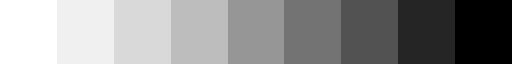

In [18]:
cmap

In [19]:
custom_palette = [mpl.colors.rgb2hex(cmap(i)) for i in range(cmap.N)]

In [20]:
custom_palette= custom_palette[5:6]

In [21]:
review.groupby(['Year']).size().index

Index([2018, 2019, 2020, 2022, 2023, 2024, 2025], dtype='int64', name='Year')

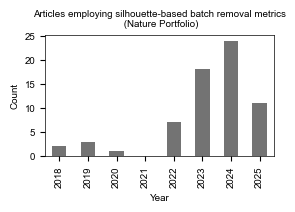

In [22]:
pd.concat([review.groupby(['Year']).size(),(pd.Series({2021: 0}))]).sort_index(ascending=True).plot.bar(stacked=True, color=custom_palette)
plt.title('Articles employing silhouette-based batch removal metrics\n (Nature Portfolio)')
plt.ylabel('Count')
plt.xlabel('Year')
plt.savefig('./../figures/silhouette_based_batch_removal_usage_20250410.png', format='png', dpi=600, bbox_inches='tight')